# Substack sample


This notebook uses the two tables extracted from that zip:

- `monthly_coverage.csv` — one row per month and topic (648 rows)
- `monthly_manifests.csv` — one row per month (81 rows), from the delivery manifests

Publication window: January 2020 through 17 September 2026. The pre/post split is December 2022, the first full month after ChatGPT's public launch.

This is the selected sample, not the raw crawl. The 4.43 GB shard tar and the Medium snapshot are not used here.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

candidates = [
    Path("data/substack_eda"),
    Path("../data/substack_eda"),
    Path("/Users/kofibadu/Desktop/cap folder/data/substack_eda"),
]
DATA = next(p for p in candidates if (p / "monthly_coverage.csv").exists())

coverage = pd.read_csv(DATA / "monthly_coverage.csv")
manifests = pd.read_csv(DATA / "monthly_manifests.csv")
coverage["year_month"] = pd.to_datetime(coverage["year_month"] + "-01")
manifests["month"] = pd.to_datetime(manifests["month"] + "-01")
CUT = pd.Timestamp("2022-12-01")

for col in ["eligible_candidate_creators", "sampled_creators", "topic_floor_target", "topic_floor_shortfall", "pending_publications"]:
    coverage[col] = pd.to_numeric(coverage[col])

print(f"coverage rows: {len(coverage):,}   months: {manifests['month'].nunique()}")
print(f"every month passed validation: {bool(manifests['validation_passed'].all())}")
print(f"pending publications on every coverage row: {sorted(coverage['pending_publications'].unique())}")


coverage rows: 648   months: 81
every month passed validation: True
pending publications on every coverage row: [37314]


## Sample size

The design keeps up to 2,500 eligible creators each month. Eligible means the creator had a qualifying public post that month. January and February 2020 are below the cap because fewer than 2,500 creators were eligible.


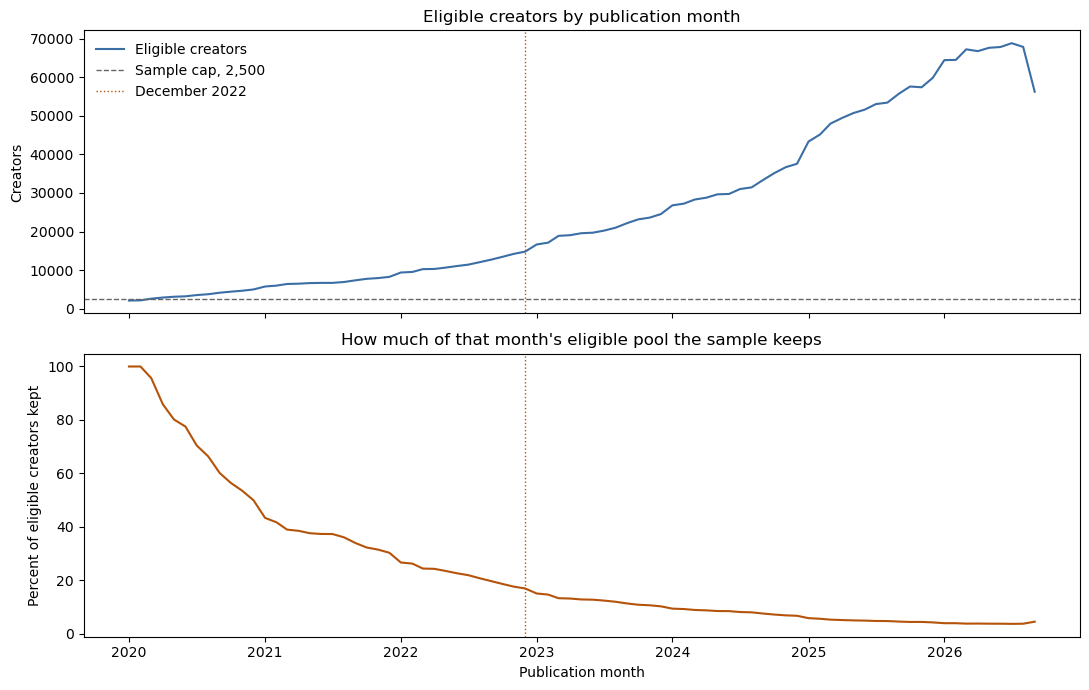

,year_month,eligible,sampled,kept_pct
0,2020-01,2128,2128,100.000000
34,2022-11,14237,2500,17.559879
35,2022-12,14802,2500,16.889610
78,2026-07,68800,2500,3.633721
80,2026-09,56221,2500,4.446737


In [2]:
month = (
    coverage.groupby("year_month", as_index=False)
    .agg(eligible=("eligible_candidate_creators", "sum"), sampled=("sampled_creators", "sum"))
)
month["kept_pct"] = 100 * month["sampled"] / month["eligible"]
manifests = manifests.merge(
    month.rename(columns={"year_month": "month"}),
    on="month",
    how="left",
)
manifests["posts_per_creator"] = manifests["unique_selected_texts"] / manifests["creator_months"]
manifests["period"] = manifests["month"].ge(CUT).map({False: "pre", True: "post"})

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(month["year_month"], month["eligible"], color="#3b6ea5", label="Eligible creators")
axes[0].axhline(2500, color="#666666", ls="--", lw=1, label="Sample cap, 2,500")
axes[0].axvline(CUT, color="#b45309", ls=":", lw=1, label="December 2022")
axes[0].set_ylabel("Creators")
axes[0].set_title("Eligible creators by publication month")
axes[0].legend(frameon=False, loc="upper left")

axes[1].plot(month["year_month"], month["kept_pct"], color="#b45309")
axes[1].axvline(CUT, color="#b45309", ls=":", lw=1)
axes[1].set_ylabel("Percent of eligible creators kept")
axes[1].set_xlabel("Publication month")
axes[1].set_title("How much of that month's eligible pool the sample keeps")
fig.tight_layout()
plt.show()

checkpoints = month[month["year_month"].isin(pd.to_datetime(["2020-01-01", "2022-11-01", "2022-12-01", "2026-07-01", "2026-09-01"]))]
checkpoints.assign(year_month=checkpoints["year_month"].dt.strftime("%Y-%m"))


## Selected posts

Each selected creator contributes 1 to 3 public posts that month. That cap is why post counts stay near 5,100 even if people started publishing more often after ChatGPT.


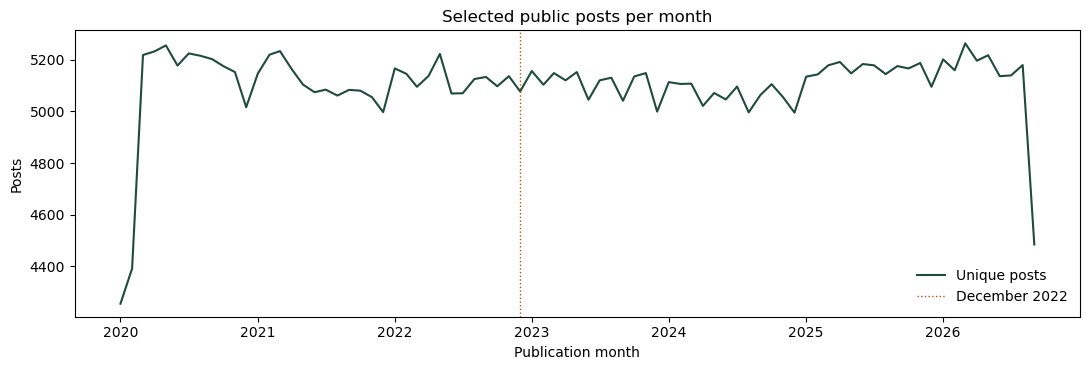

creator-months: 201,810
unique posts: 413,252
assignment rows, including coauthors: 414,898
extra coauthor links: 1,646
posts per creator-month: 2.048
pre  mean posts/month: 5092 over 35 months
post mean posts/month: 5110 over 46 months
partial month: ['2026-09']


In [3]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(manifests["month"], manifests["unique_selected_texts"], color="#1f4b3a", label="Unique posts")
ax.axvline(CUT, color="#b45309", ls=":", lw=1, label="December 2022")
ax.set_ylabel("Posts")
ax.set_xlabel("Publication month")
ax.set_title("Selected public posts per month")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

pre = manifests[manifests["period"] == "pre"]
post = manifests[manifests["period"] == "post"]
print(f"creator-months: {int(manifests['creator_months'].sum()):,}")
print(f"unique posts: {int(manifests['unique_selected_texts'].sum()):,}")
print(f"assignment rows, including coauthors: {int(manifests['selected_text_assignments'].sum()):,}")
print(f"extra coauthor links: {int((manifests['selected_text_assignments'] - manifests['unique_selected_texts']).sum()):,}")
print(f"posts per creator-month: {manifests['unique_selected_texts'].sum() / manifests['creator_months'].sum():.3f}")
print(f"pre  mean posts/month: {pre['unique_selected_texts'].mean():.0f} over {len(pre)} months")
print(f"post mean posts/month: {post['unique_selected_texts'].mean():.0f} over {len(post)} months")
print("partial month:", manifests.loc[manifests["is_partial_month"], "month"].dt.strftime("%Y-%m").tolist())


## Topics

Eight keyword families. The sampler tries to keep at least 150 creators in each family every month. Society, history and ideas takes about a third of the slots in every year, so an unweighted monthly average will mostly reflect that family.


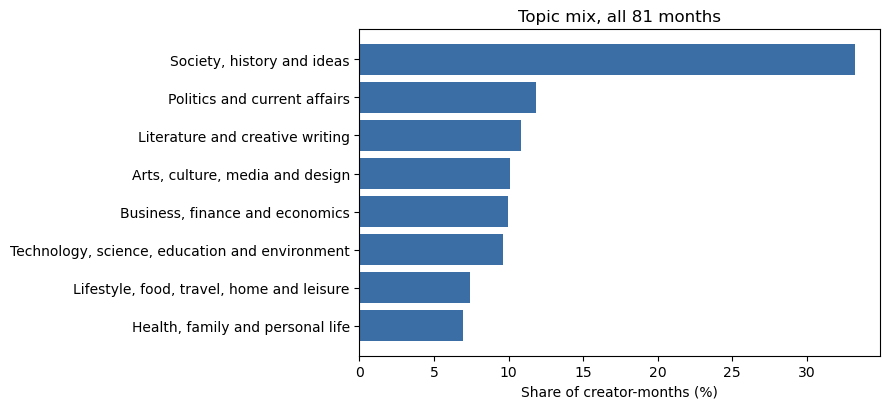

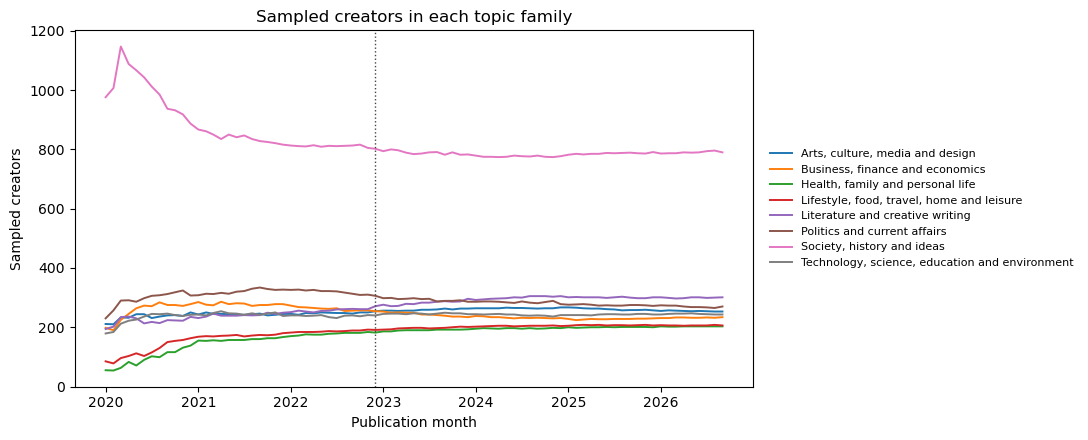

topic-months below the 150 floor: 20 of 648


,year_month,topic_family,eligible_candidate_creators,sampled_creators,topic_floor_shortfall
6,2020-01,"Health, family and personal life",55,55,95
7,2020-01,"Lifestyle, food, travel, home and leisure",85,85,65
14,2020-02,"Health, family and personal life",54,54,96
15,2020-02,"Lifestyle, food, travel, home and leisure",78,78,72
22,2020-03,"Health, family and personal life",63,63,87
23,2020-03,"Lifestyle, food, travel, home and leisure",96,96,54
30,2020-04,"Health, family and personal life",83,83,67
31,2020-04,"Lifestyle, food, travel, home and leisure",103,103,47
38,2020-05,"Health, family and personal life",71,71,79
39,2020-05,"Lifestyle, food, travel, home and leisure",112,112,38


In [4]:
topic_totals = (
    coverage.groupby("topic_family", as_index=False)["sampled_creators"]
    .sum()
    .sort_values("sampled_creators")
)
topic_totals["share_pct"] = 100 * topic_totals["sampled_creators"] / topic_totals["sampled_creators"].sum()

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(topic_totals["topic_family"], topic_totals["share_pct"], color="#3b6ea5")
ax.set_xlabel("Share of creator-months (%)")
ax.set_title("Topic mix, all 81 months")
fig.tight_layout()
plt.show()

wide = coverage.pivot(index="year_month", columns="topic_family", values="sampled_creators")
fig, ax = plt.subplots(figsize=(11, 4.5))
for name in wide.columns:
    ax.plot(wide.index, wide[name], lw=1.4, label=name)
ax.axvline(CUT, color="#444444", ls=":", lw=1)
ax.set_ylabel("Sampled creators")
ax.set_xlabel("Publication month")
ax.set_title("Sampled creators in each topic family")
ax.legend(frameon=False, fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.tight_layout()
plt.show()

short = coverage.loc[coverage["topic_floor_shortfall"] > 0,
    ["year_month", "topic_family", "eligible_candidate_creators", "sampled_creators", "topic_floor_shortfall"]].copy()
short["year_month"] = short["year_month"].dt.strftime("%Y-%m")
print(f"topic-months below the 150 floor: {len(short)} of {len(coverage)}")
short


## Before and after December 2022

Post-period months are not a larger writing sample. They are the same cap applied to a much bigger eligible pool.


In [5]:
def block(df, label):
    full = df[~df["is_partial_month"]]
    return {
        "period": label,
        "months": int(len(df)),
        "mean eligible creators": int(round(df["eligible"].mean())),
        "mean sampled creators": int(round(df["sampled"].mean())),
        "mean kept %": round(df["kept_pct"].mean(), 1),
        "mean posts": int(round(full["unique_selected_texts"].mean())),
        "mean posts per creator": round(df["posts_per_creator"].mean(), 3),
    }

compare = pd.DataFrame([block(pre, "through Nov 2022"), block(post, "Dec 2022 onward")])
compare


,period,months,mean eligible creators,mean sampled creators,mean kept %,mean posts,mean posts per creator
0,through Nov 2022,35,7144,2480,45.1,5092,2.052
1,Dec 2022 onward,46,40273,2500,7.7,5124,2.044


## Reading the result

The delivered Substack sample is large enough for a monthly series: about 2,500 creators and 5,100 public posts in every full month, and every month's manifest passed validation.

Three limits belong in any later write-up.

1. **37,314 publications were still uncollected** when this zip was frozen. A later crawl can change who would have been eligible.
2. **The kept share falls from 100% in early 2020 to about 4% in 2026.** A change in the monthly average can be a change in who makes the cap, not a change in how the same writers write.
3. **Volume cannot rise inside this file.** The sampler keeps 1–3 posts per creator-month, so this notebook cannot test whether people published more after ChatGPT. Style comparisons have to use the post text in the zip, which is not loaded here.


## How often the same creator returns

Each month is its own draw of up to 2,500 eligible creators. The creator-month files inside the zip say which creator was kept, how many qualifying public posts they had, and how many of those were selected (capped at 3).

Across all 81 months there are 24,744 distinct creators. 3,793 of them appear at least once before December 2022 and at least once after. 10,389 appear only before that cut, and 10,562 appear only after.


creators: 24,744
in exactly one month: 5,435
in all 81 months: 4
median months in the sample: 5


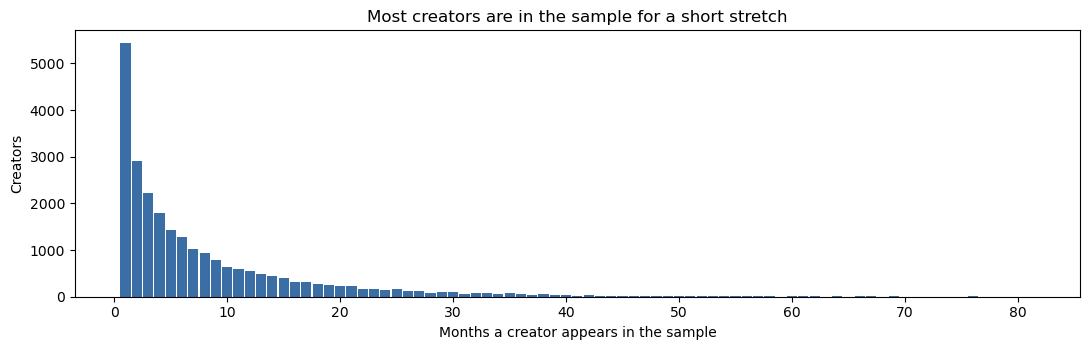

In [6]:
repeat = pd.read_csv(DATA / "creator_repeat.csv")
print(f"creators: {int(repeat['creators'].sum()):,}")
print(f"in exactly one month: {int(repeat.loc[repeat['months_in_sample']==1, 'creators'].sum()):,}")
print(f"in all 81 months: {int(repeat.loc[repeat['months_in_sample']==81, 'creators'].sum()):,}")
print(f"median months in the sample: {repeat.loc[repeat.index.repeat(repeat['creators']), 'months_in_sample'].median():.0f}")

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(repeat["months_in_sample"], repeat["creators"], color="#3b6ea5", width=0.9)
ax.set_xlabel("Months a creator appears in the sample")
ax.set_ylabel("Creators")
ax.set_title("Most creators are in the sample for a short stretch")
fig.tight_layout()
plt.show()


## Posts written versus posts kept

`qualifying_posts` is the creator's public text count that month, before the 1–3 cap. `selected_posts` is what entered the sample. The median creator has 2 qualifying posts in every month, so the cap binds for the upper tail: about a third of creator-months have 4 or more qualifying posts.


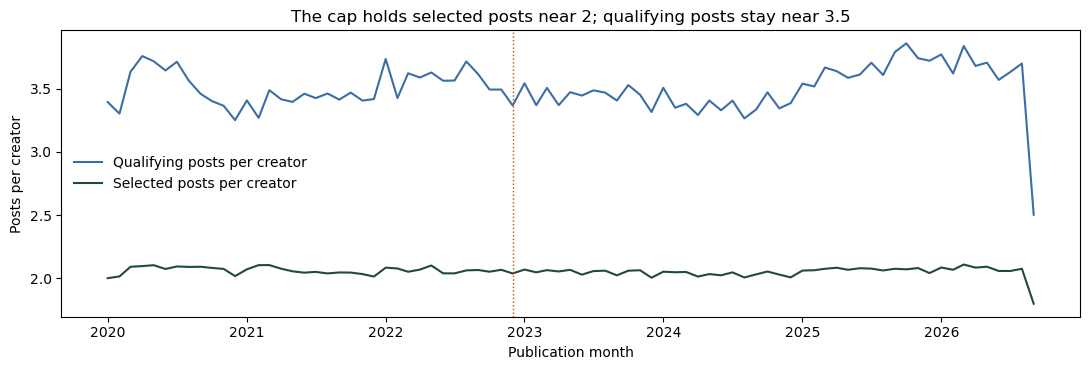

,period,qualifying per creator,selected per creator,share with 4+ qualifying posts %
0,through Nov 2022,3.507,2.064,32.5
1,Dec 2022 through Aug 2026,3.527,2.055,31.2


In [7]:
volume = pd.read_csv(DATA / "creator_month_volume.csv", parse_dates=["year_month"])
volume["qual_per_creator"] = volume["qualifying_posts"] / volume["sampled_creators"]
volume["sel_per_creator"] = volume["selected_posts"] / volume["sampled_creators"]
volume["share_4plus"] = 100 * volume["creators_with_4plus"] / volume["sampled_creators"]
volume["period"] = volume["year_month"].ge(CUT).map({False: "pre", True: "post"})

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(volume["year_month"], volume["qual_per_creator"], color="#3b6ea5", label="Qualifying posts per creator")
ax.plot(volume["year_month"], volume["sel_per_creator"], color="#1f4b3a", label="Selected posts per creator")
ax.axvline(CUT, color="#b45309", ls=":", lw=1)
ax.set_ylabel("Posts per creator")
ax.set_xlabel("Publication month")
ax.set_title("The cap holds selected posts near 2; qualifying posts stay near 3.5")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

full = volume[volume["year_month"] < "2026-09-01"]
def vblock(df, label):
    return {
        "period": label,
        "qualifying per creator": round(df["qualifying_posts"].sum() / df["sampled_creators"].sum(), 3),
        "selected per creator": round(df["selected_posts"].sum() / df["sampled_creators"].sum(), 3),
        "share with 4+ qualifying posts %": round(100 * df["creators_with_4plus"].sum() / df["sampled_creators"].sum(), 1),
    }
pd.DataFrame([
    vblock(full[full["period"]=="pre"], "through Nov 2022"),
    vblock(full[full["period"]=="post"], "Dec 2022 through Aug 2026"),
])


## Length and engagement of the selected posts

These figures come from every `posts_meta.csv` in the zip: 413,252 posts. Every selected post is marked public (`is_paywalled` is false). 407,063 are labeled English and 6,189 have a blank language field.

Likes and comments were recorded between 21 September and 2 October 2026, the same checkpoint for every month. A 2020 post has had longer to collect them than a 2026 post.


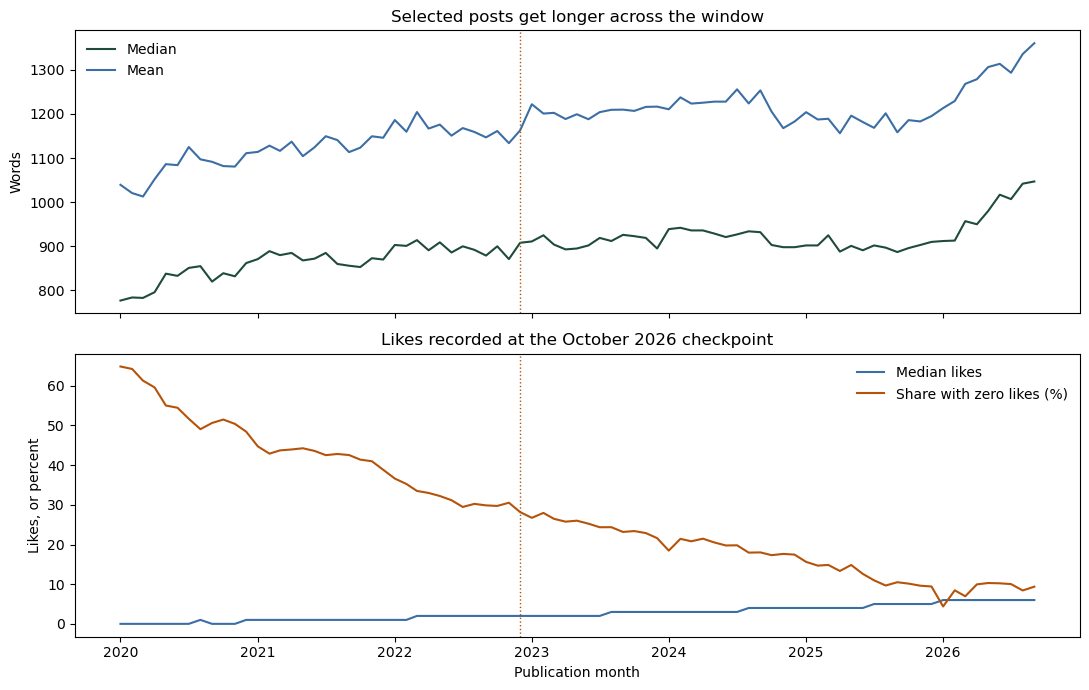

posts: 413,252
paywalled: 0
median words, 2020-01: 777
median words, 2022-11: 871
median words, 2026-08: 1042
zero-like share, 2020-01: 64.9%
zero-like share, 2026-08: 8.4%
median comments stays 0 through 2025-11 and is 1 from 2025-12


In [8]:
posts = pd.read_csv(DATA / "post_length_engagement.csv", parse_dates=["year_month"])
posts["zero_like_pct"] = 100 * posts["zero_likes"] / posts["posts"]
posts["zero_comment_pct"] = 100 * posts["zero_comments"] / posts["posts"]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(posts["year_month"], posts["median_words"], color="#1f4b3a", label="Median")
axes[0].plot(posts["year_month"], posts["mean_words"], color="#3b6ea5", label="Mean")
axes[0].axvline(CUT, color="#b45309", ls=":", lw=1)
axes[0].set_ylabel("Words")
axes[0].set_title("Selected posts get longer across the window")
axes[0].legend(frameon=False)

axes[1].plot(posts["year_month"], posts["median_likes"], color="#3b6ea5", label="Median likes")
axes[1].plot(posts["year_month"], posts["zero_like_pct"], color="#b45309", label="Share with zero likes (%)")
axes[1].axvline(CUT, color="#b45309", ls=":", lw=1)
axes[1].set_ylabel("Likes, or percent")
axes[1].set_xlabel("Publication month")
axes[1].set_title("Likes recorded at the October 2026 checkpoint")
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"posts: {int(posts['posts'].sum()):,}")
print(f"paywalled: {int(posts['paywalled'].sum())}")
print(f"median words, 2020-01: {int(posts.loc[posts['year_month']=='2020-01-01','median_words'].iloc[0])}")
print(f"median words, 2022-11: {int(posts.loc[posts['year_month']=='2022-11-01','median_words'].iloc[0])}")
print(f"median words, 2026-08: {int(posts.loc[posts['year_month']=='2026-08-01','median_words'].iloc[0])}")
print(f"zero-like share, 2020-01: {posts.loc[posts['year_month']=='2020-01-01','zero_like_pct'].iloc[0]:.1f}%")
print(f"zero-like share, 2026-08: {posts.loc[posts['year_month']=='2026-08-01','zero_like_pct'].iloc[0]:.1f}%")
print(f"median comments stays 0 through 2025-11 and is 1 from 2025-12")


## What this adds

The monthly post count stays flat because of the sampler, and the underlying qualifying counts are flat too: about 3.5 public posts per selected creator before December 2022 and about 3.5 after. The median writer is under the cap. About 32% of creator-months are cut from 4 or more posts down to 3.

Length moves. The median selected post grows from 777 words in January 2020 to 871 in November 2022 and 1,042 in August 2026.

Only 3,793 creators are observed on both sides of December 2022. A within-writer comparison has to use that group. The other 20,951 creators appear on only one side of the cut.

Likes rise for more recent posts even though those posts have had less time to collect them. The comment median stays at 0 until December 2025. Both series are checkpoint totals, so they are a weak measure of engagement in the month the post was published.



## Did the length trend bend in December 2022?

A pre/post average hides a trend that was already underway. Each full month is one point. The line allows a slope before December 2022, a jump in that month, and a different slope afterward. September 2026 is left out because the month is partial.

The same fit is run twice: on every selected post, and on the posts of the 3,793 creators who appear at least once before December 2022 and at least once after.


In [9]:
import numpy as np

overlap = pd.read_csv(DATA / "overlap_length.csv", parse_dates=["year_month"])
paired = pd.read_csv(DATA / "overlap_paired.csv").iloc[0]

def broken_line(frame, ycol):
    d = frame[frame["year_month"] < "2026-09-01"].copy()
    d["t"] = (d["year_month"].dt.year - 2020) * 12 + (d["year_month"].dt.month - 1)
    cut = 35  # 2022-12
    d["post"] = (d["t"] >= cut).astype(float)
    d["t_post"] = np.maximum(d["t"] - cut, 0.0)
    X = np.column_stack([np.ones(len(d)), d["t"], d["post"], d["t_post"]])
    y = d[ycol].to_numpy(float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    dof = len(y) - X.shape[1]
    sigma2 = float(resid @ resid) / dof
    se = np.sqrt(np.diag(sigma2 * np.linalg.inv(X.T @ X)))
    d["fitted"] = X @ beta
    return d, beta, se

def report(label, beta, se):
    pre = beta[1]
    jump = beta[2]
    change = beta[3]
    post = pre + change
    return {
        "series": label,
        "pre slope, words per month": round(pre, 2),
        "post slope, words per month": round(post, 2),
        "change in slope": round(change, 2),
        "change / SE": round(change / se[3], 2),
        "level jump in Dec 2022": round(jump, 1),
        "jump / SE": round(jump / se[2], 2),
    }

all_fit, all_b, all_se = broken_line(posts, "median_words")
over_fit, over_b, over_se = broken_line(overlap, "median_words")
slope_table = pd.DataFrame([
    report("all selected posts", all_b, all_se),
    report("creators on both sides", over_b, over_se),
])
slope_table


,series,"pre slope, words per month","post slope, words per month",change in slope,change / SE,level jump in Dec 2022,jump / SE
0,all selected posts,2.89,1.04,-1.86,-3.36,-14.7,-1.19
1,creators on both sides,4.01,0.69,-3.31,-5.22,-2.9,-0.20


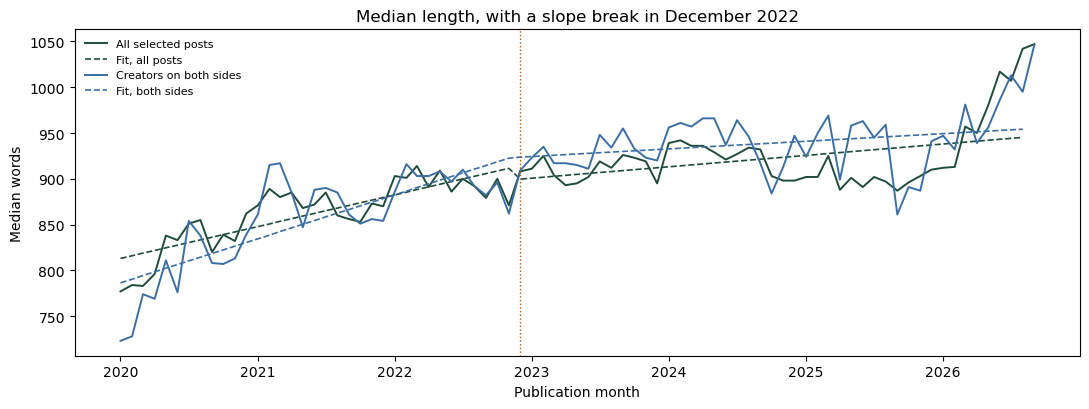

creators with posts on both sides: 3,793
their mean post length before Dec 2022: 1172 words
their mean post length from Dec 2022 on: 1262 words
median creator's change: 51 words
middle half of creator changes: -164 to 319 words


In [10]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(posts["year_month"], posts["median_words"], color="#1f4b3a", lw=1.4, label="All selected posts")
ax.plot(all_fit["year_month"], all_fit["fitted"], color="#1f4b3a", ls="--", lw=1.2, label="Fit, all posts")
ax.plot(overlap["year_month"], overlap["median_words"], color="#3b6ea5", lw=1.4, label="Creators on both sides")
ax.plot(over_fit["year_month"], over_fit["fitted"], color="#3b6ea5", ls="--", lw=1.2, label="Fit, both sides")
ax.axvline(CUT, color="#b45309", ls=":", lw=1)
ax.set_ylabel("Median words")
ax.set_xlabel("Publication month")
ax.set_title("Median length, with a slope break in December 2022")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

print(f"creators with posts on both sides: {int(paired['creators']):,}")
print(f"their mean post length before Dec 2022: {paired['mean_words_pre']:.0f} words")
print(f"their mean post length from Dec 2022 on: {paired['mean_words_post']:.0f} words")
print(f"median creator's change: {paired['median_creator_diff']:.0f} words")
print(f"middle half of creator changes: {paired['p25_creator_diff']:.0f} to {paired['p75_creator_diff']:.0f} words")


## Reading the slope check

Length was already rising before ChatGPT, about 2.9 words a month in the full sample, and about 4.0 words a month among creators who appear on both sides. After December 2022 those slopes fall to about 1.0 and 0.7 words a month. The level jump in December 2022 itself is small relative to the noise in the monthly medians.

The within-writer average still moves up: those 3,793 creators' posts average about 1,172 words before the cut and about 1,263 after. The median creator's own change is about 50 words, and the middle half of creators runs from a decline of about 160 words to a gain of about 320. A higher average can sit on top of a trend that was already in place.

This is a description of monthly medians and of each creator's own pre and post mean. It is the length check. Homogeneity of style still requires the post text.
